Compare the fit you get when you chunk the data by redshfit vs. when you use time-evolving parameters

In [63]:
from escripts import eMCMC
from escripts import eplots
from escripts import edata
from matplotlib.gridspec import GridSpec
import math

In [109]:
def piecewise_vs_deriv(param_chunks, param_bases, param_derivs, labels, z_midponts = [5, 8, 11.15], ncols = 2):
    # Figure out how many subplots to make
    n = len(param_bases)
    fig = plt.figure()
    gs = GridSpec(math.ceil((n+1)/ncols), ncols, figure=fig)
    
    # Adjust size & spacing
    fig.set_size_inches(4*ncols, 4*math.ceil((n+1)/ncols))
    plt.subplots_adjust(wspace = 0.2, hspace = 0.3)

    axs = []

    for i, (chunk, base, deriv, label) in enumerate(zip (param_chunks, param_bases, param_derivs, labels)):
        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)
        ax.plot(z_midpoints, z_ev(base, deriv, z_midpoints), label = 'base + derivative', color = eplots.turquoise, ls = 'solid')
        ax.plot(z_midpoints, chunk, color = eplots.green, ls = 'dotted', label = 'piecewise')
        ax.set_title(label)

    axs[0].legend()

    return fig

def z_ev(base, deriv, z):
    return base + deriv*(z-8)  

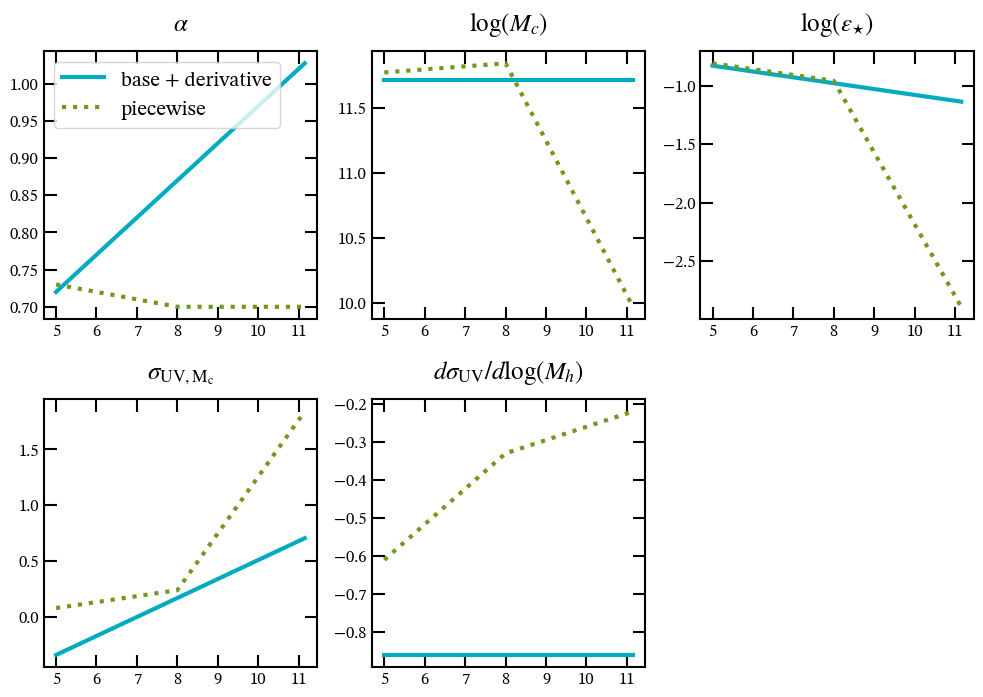

In [110]:
param_chunks = [[0.73, 0.7, 0.7], [11.77, 11.84, 9.97], [-0.81, -0.96, -2.89], [0.08, 0.24, 1.84], [-0.61, -0.33, -0.22]]
param_bases = [0.87, 11.71, -0.98, 0.17, -0.86]
param_derivs = [0.05, 0, -0.05, 0.17, 0]
labels = [r'$\alpha$', r'$\log(M_c)$', r"$\log(\epsilon_{\star})$", r'$\sigma_{\rm{UV}, M_c}$', r'$d\sigma_{\rm{UV}}/d\log(M_{h})$']
piecewise_fig = piecewise_vs_deriv(param_chunks, param_bases, param_derivs, labels, ncols = 3)

In [111]:
piecewise_fig.savefig('/Users/eb35267/Desktop/code/home/figures/piecewise_vs_deriv.png', bbox_inches='tight')

# Test chi squared for piecewise fit

In [61]:
eMCMC.get_default_df()

,fit,value,lower,upper,label
alpha,True,0.6,0,4,$\alpha$
dalphadz,True,0,-0.5,0.5,$d\alpha/dz$
beta,True,-0.5,-3,0,$\beta$
dbetadz,True,0,-1,1.5,$d\beta/dz$
logMc,True,12,9,16,$\log(M_c)$
dlogMcdz,True,0,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-4.5,0,$\log(\epsilon_{\star})$
dlogedz,True,0,-0.5,0.5,$d\log(\epsilon_{\star})/dz$
sig,True,0,0,6,"$\sigma_{\rm{UV}, M_c}$"
dsigdz,True,0,-1,1,$d\sigma_{\rm{UV}}/dz$


In [ ]:
param_chunks = [[0.73, 0.7, 0.7], [11.77, 11.84, 9.97], [-0.81, -0.96, -2.89], [0.08, 0.24, 1.84], [-0.61, -0.33, -0.22]]

In [95]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt',]
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

# Initialize parameters
params = eMCMC.build_param_data({'beta': {'fit':False, 'value': -0.54}, 'dbetadz': {'fit': False, 'value':0}})


In [96]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [101]:
piecewise_fit = [[0.73, 0.73, 0.73, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7], 0, [11.77, 11.77, 11.77, 11.84, 11.84, 11.84, 9.97, 9.97, 9.97], 0,
            [-0.81, -0.81, -0.81, -0.96, -0.96, -0.96, -2.89, -2.89, -2.89], 0, 
            [0.08, 0.08, 0.08, 0.24, 0.24, 0.24, 1.84, 1.84, 1.84], 0, [-0.61, -0.61, -0.61, -0.33, -0.33, -0.33, -0.22, -0.22, -0.22]]
deriv_fit = [0.88, 0.06, 11.7, 0, -0.98, -0.05, 0.18, 0.17, -0.89]

In [102]:
# Initialize UVLF object
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [107]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:215: RuntimeWarning: divide by zero encountered in log10
  if dat_z[-1]: # This indicates whether the data was used in the MCMC likelihood or not:
/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:215: RuntimeWarning: divide by zero encountered in log10
  if dat_z[-1]: # This indicates whether the data was used in the MCMC likelihood or not:
/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:215: RuntimeWarning: invalid value encounte

here


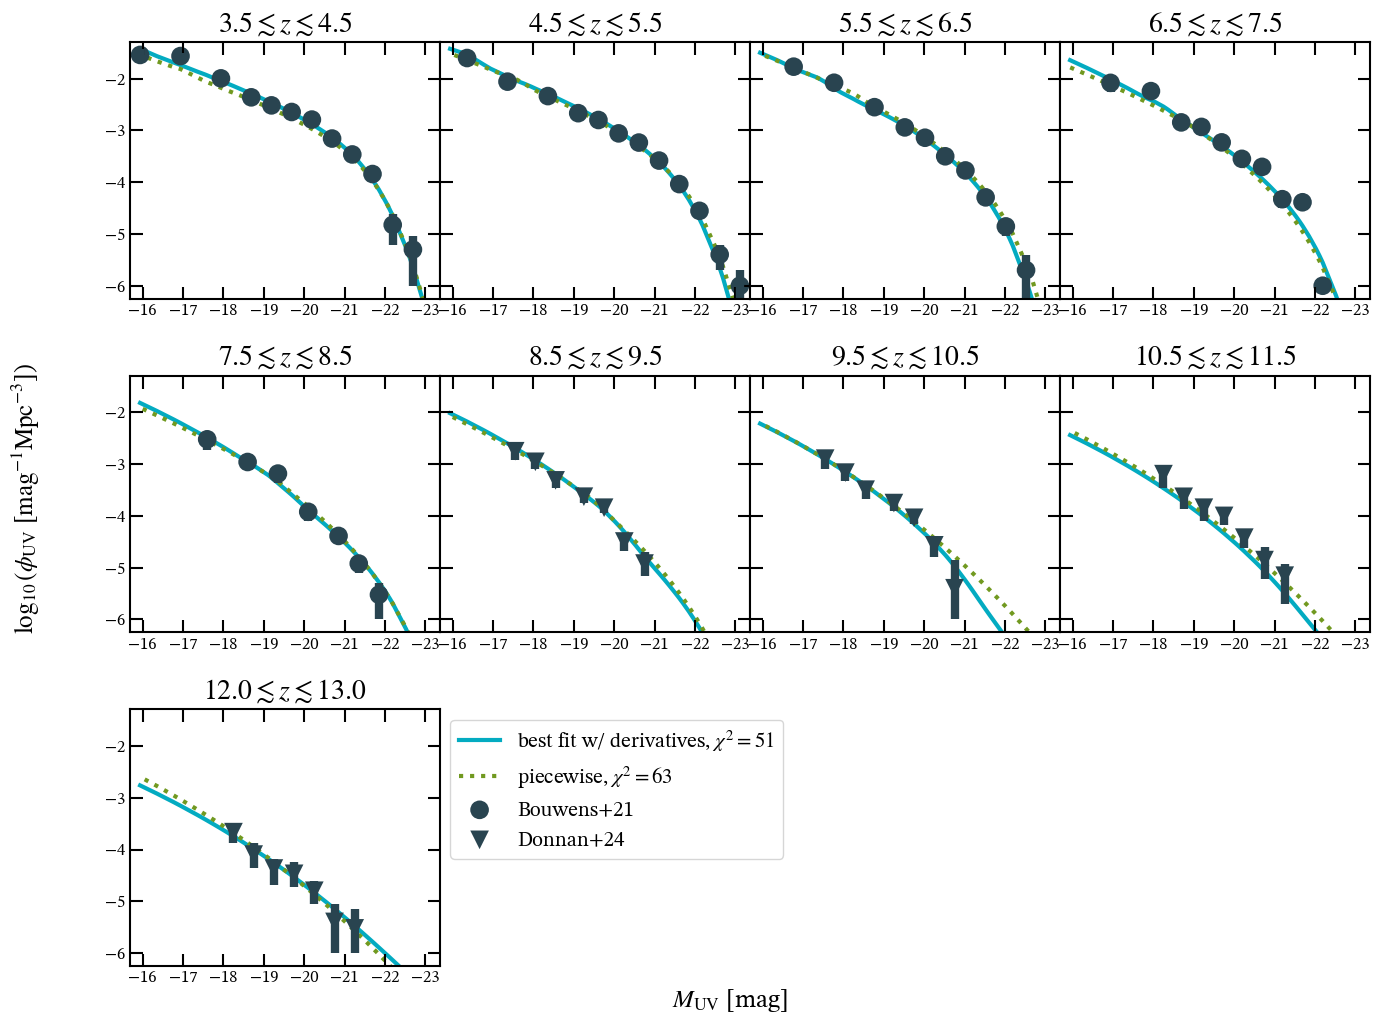

In [108]:
comparison_fig = eplots.evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [deriv_fit, piecewise_fit], 
                               comparison_labels = ['best fit w/ derivatives', 'piecewise'], 
                               title = '', ncols = 4)

In [112]:
comparison_fig.savefig('/Users/eb35267/Desktop/code/home/figures/deriv_vs_piecewise_uvlf.png', bbox_inches='tight')